In [494]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import invgamma

# Exercice 1
## 1.A - MH within a Random Scan Gibbs sampler
### Question 1
On appelle cet algo Gibbs sampler parce qu'on fait du sampling d'une seule coordonnée à la fois. Cependant, le choix de la coordonnée est aléatoire (probabilité $1/2$ pour chaque coordonnée), d'où le terme 'random scan'.


Dans cet algorithme, on utilise Metropolis-Hastings lors de la mise à jour d'une coordonnée. On utilise un random walk gaussien et symétrique, et on accepte ou rejette pour chaque noyau de transition.
### Question 2

In [495]:
def pi_dist(z, a):
    return np.exp(-z[0]**2/a**2
                  - z[1]**2
                  - 1/4*(z[0]**2/a**2
                         - z[1]**2)**2)

In [496]:
def sample_P1(z, sigma1, dist):
    z_prop = z.copy()
    z_prop[0] = z[0] + np.random.normal(0, sigma1)

    ratio = dist(z_prop) / dist(z)
    alpha = min(ratio, 1)

    u = np.random.uniform()
    if u < alpha:
        return z_prop, alpha, True
    else:
        return z, alpha, False


In [497]:
def sample_P2(z, sigma2, dist):
    z_prop = z.copy()
    z_prop[1] = z[1] + np.random.normal(0, sigma2)

    ratio = dist(z_prop) / dist(z)
    alpha = min(ratio, 1)

    u = np.random.uniform()
    if u < alpha:
        return z_prop, alpha, True
    else:
        return z, alpha, False


In [498]:
# petit test
sample_P1([0, 0], 1, lambda z: pi_dist(z, 10))

([0.7691853812990965, 0], np.float64(0.9940923068159214), True)

In [499]:
def sample_P(z, sigma1, sigma2, dist, p, acc_x, acc_y, tried_x, tried_y):
    """
    Échantillonnage d'une coordonnée au choix.
    On garde la trace du nombre de fois 
    - où l'on a échantillonné chaque coordonnée
    - et du nombre d'acceptations.
    """
    # choix de la coordonnée à échantillonner
    u = np.random.uniform()
    if u < p:
        new_z, alpha, acc = sample_P1(z, sigma1, dist)
        acc_x += acc
        tried_x += 1
    else:
        new_z, alpha, acc = sample_P2(z, sigma2, dist)
        acc_y += acc
        tried_y += 1
    return new_z, alpha, acc_x, acc_y, tried_x, tried_y


In [500]:
def sample_MC(z, sigma1, sigma2, dist, p=1/2, maxiter=500, track_every=50):

    chain = [z.copy()]
    # À réinitialiser après track_every itérations
    acc_x = 0
    acc_y = 0
    tried_x = 0
    tried_y = 0

    # Les taux d'acceptation par "époque" de track_every itérations
    mean_acc_x = []
    mean_acc_y = []

    curr_z = z.copy()
    for i in range(1, maxiter + 1):
        # Échantillonnage
        curr_z, _, acc_x, acc_y, tried_x, tried_y = sample_P(
            curr_z, sigma1, sigma2, dist, p, acc_x, acc_y, tried_x, tried_y
        )
        chain.append(curr_z.copy())

        # Taux d'acceptation effectifs
        if i % track_every == 0:
            mean_acc_x.append(acc_x / tried_x if tried_x > 0 else 0)
            mean_acc_y.append(acc_y / tried_y if tried_y > 0 else 0)
            acc_x = 0
            acc_y = 0
            tried_x = 0
            tried_y = 0

    return np.array(chain), mean_acc_x, mean_acc_y


### Question 3

In [501]:
track_every = 50
not_adaptive_samples, mean_acc_x, mean_acc_y = sample_MC(
    z=np.array([0., 0.]), sigma1=3, sigma2=3, dist=lambda z: pi_dist(z, 10),
    p=1/2, maxiter=2000, track_every=track_every
)

In [502]:
def plot_taux_acc(acc_rates, track_every, algo_titre=""):
    """
    Trace les taux d'acceptation moyens pour plusieurs coordonnées.
    """
    plt.figure(figsize=(10, 5))
    for i in range(len(acc_rates)):
        plt.plot(acc_rates[i], label=f"x{i+1}")

    plt.legend()
    plt.title(f"Taux d'acceptation moyen toutes les {track_every} itérations, {algo_titre}")
    plt.ylabel("Taux d'acceptation")
    plt.show()


In [503]:
def plot_samples(chain, dist, x_min=-25, x_max=25, y_min=-2, y_max=2, n_grid=100,  algo_titre=""):
    """
    Trace les contours de la densité cible et les échantillons de la chaîne.
    """
    # Grille contours
    x = np.linspace(x_min, x_max, n_grid)
    y = np.linspace(y_min, y_max, n_grid)
    X, Y = np.meshgrid(x, y)

    # Densité
    Z = dist(np.array([X, Y]))

    # Échantillons
    samples = np.array(chain)

    plt.figure(figsize=(10, 7))
    plt.contour(X, Y, Z, cmap="plasma")
    plt.scatter(samples[:, 0], samples[:, 1])
    plt.title(f"Résultat de l'échantillonnage, {algo_titre}")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.show()


In [504]:
def plot_autocorrelations(samples, max_x=3000):
    """
    Trace les autocorrélations des coordonnées x et y des échantillons.
    """
    samples1 = np.array(samples)

    plt.figure(figsize=(13, 9))
    pd.plotting.autocorrelation_plot(samples1[:, 0], label="Autocorrélation de x", linewidth=3)
    pd.plotting.autocorrelation_plot(samples1[:, 1], label="Autocorrélation de y", linewidth=3)
    plt.xlim((0, max_x))
    plt.title("Autocorrélations")
    plt.legend()
    plt.show()


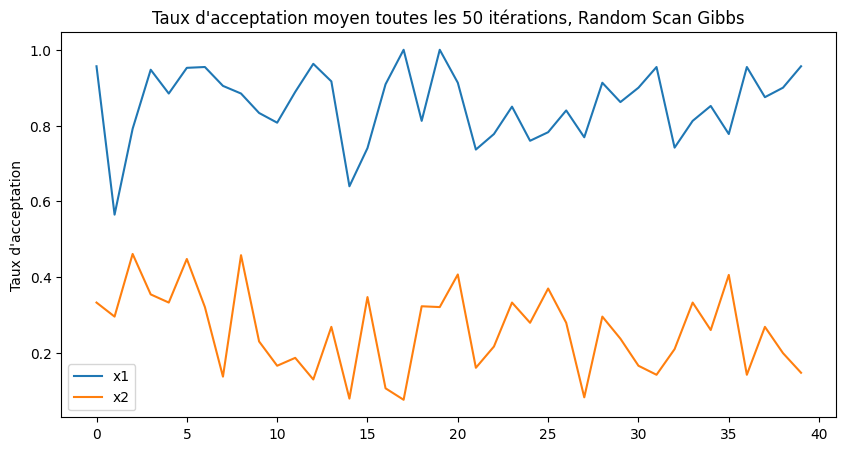

In [505]:
plot_taux_acc([mean_acc_x, mean_acc_y],
              track_every, algo_titre="Random Scan Gibbs")

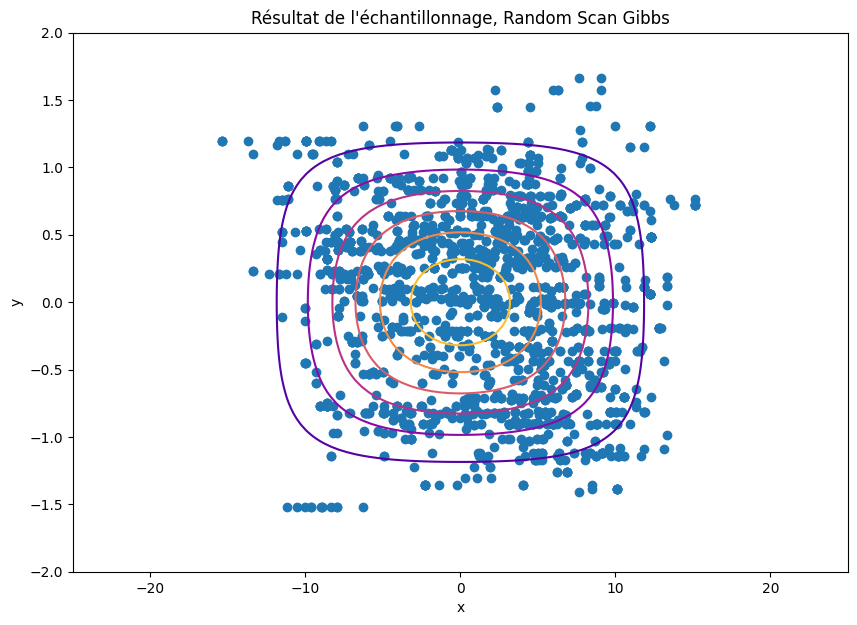

In [506]:
plot_samples(not_adaptive_samples, lambda z: pi_dist(z, 10),algo_titre="Random Scan Gibbs")

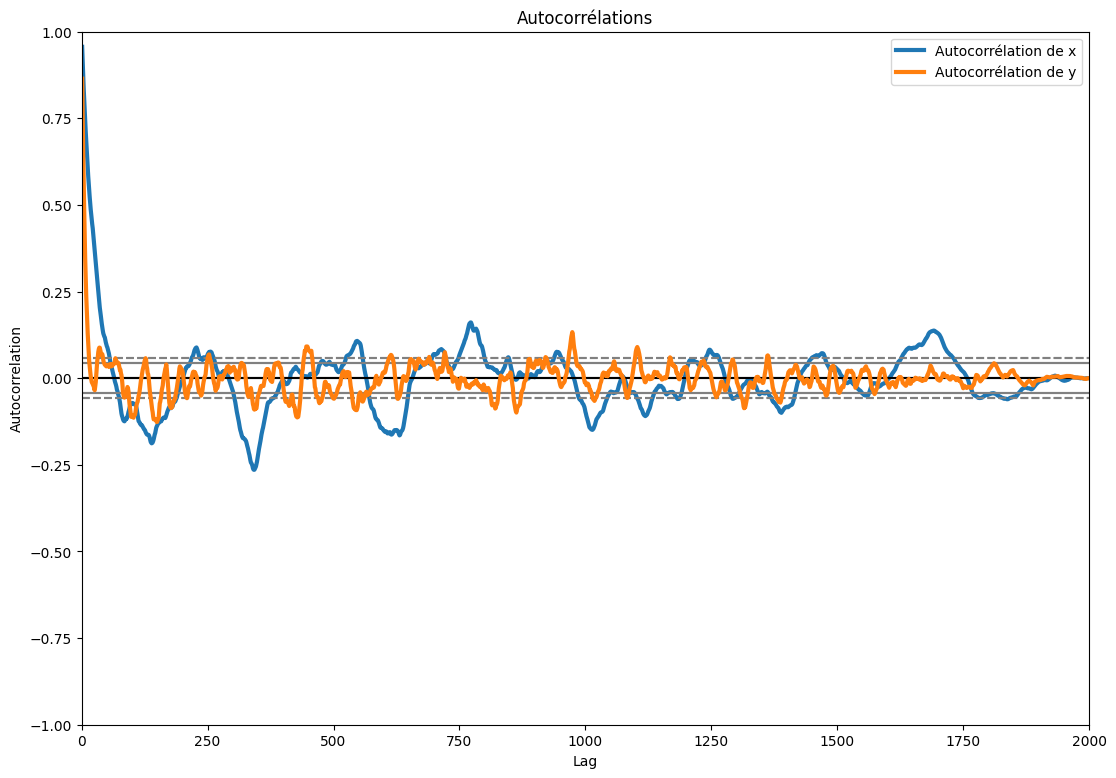

In [507]:
plot_autocorrelations(not_adaptive_samples, max_x=2000)


Sur la courbe de distribution, on voit les lignes horizontales. Ceci signifie qu'on échantillonne plusieurs fois $x$ avec le même $y$. Le taux d'acceptation de x est donc trop grand(et trop petit pour $y$). On a donc besoin d'augmenter $\sigma_{1}$ et de diminuer  $\sigma_{2}$ 

### Question 4
On va devoir adapter le taux d’acceptation en cours de route. Plus précisément, après un certain nombre d’itérations (par ex. 50), on estime le taux d’acceptation effectif et on ajuste les écarts-types pour se rapprocher d’un taux cible 0.234 


## 1.B - Adaptive MH within Gibbs sampler
### Question 1

In [508]:
def adaptiveMH_wG(x_k, dist, params_dist=None, maxiter=5000, track_every=50, sigmas=None, deltas=None):
    d = len(x_k)
    x_k = np.array(x_k, dtype=float)

    if sigmas is None:
        sigmas = [1] * d 

    all_samples = [x_k.copy()]
    acc = [0] * d
    all_acc = [[] for _ in range(d)]

    for j in range(1, maxiter + 1):
        for i in range(d):
            # proposition
            x_k_prop = x_k.copy()
            x_k_prop[i] = x_k[i] + np.random.normal(0, sigmas[i])

            # acceptation/rejet
            if params_dist is None:
                ratio = dist(x_k_prop) / dist(x_k)
            else:
                ratio = dist(x_k_prop, params_dist) / dist(x_k, params_dist)

            alpha = min(1, ratio)

            u = np.random.uniform()
            if u < alpha:
                x_k = x_k_prop.copy()
                acc[i] += 1

            all_samples.append(x_k.copy())

            # adaptation des sigmas après chaque batch
            if j % track_every == 0:
                batch = j // track_every
                delta = min(0.05, 1 / np.sqrt(batch))

                taux_acc = acc[i] / track_every
                if taux_acc < 0.234:
                    sigmas[i] = sigmas[i] / np.exp(delta)  # l - delta => sigma/exp(delta)
                else:
                    sigmas[i] = sigmas[i] * np.exp(delta)  # l + delta => sigma*exp(delta)

                all_acc[i].append(taux_acc)

        if j % track_every == 0:
            acc = [0] * d

    return all_acc, all_samples


In [509]:
track_every = 50
acc_rates_adaptive, samples_adaptive = adaptiveMH_wG([0, 0], dist= lambda z: pi_dist(z, 10), maxiter=20000, track_every=track_every)


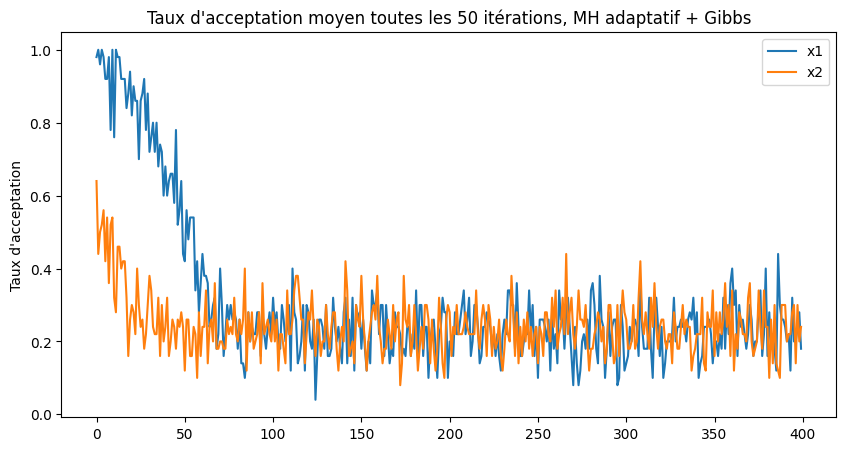

In [510]:
plot_taux_acc(acc_rates_adaptive, track_every, algo_titre="MH adaptatif + Gibbs")

L'adaptation se passe comme prévu.

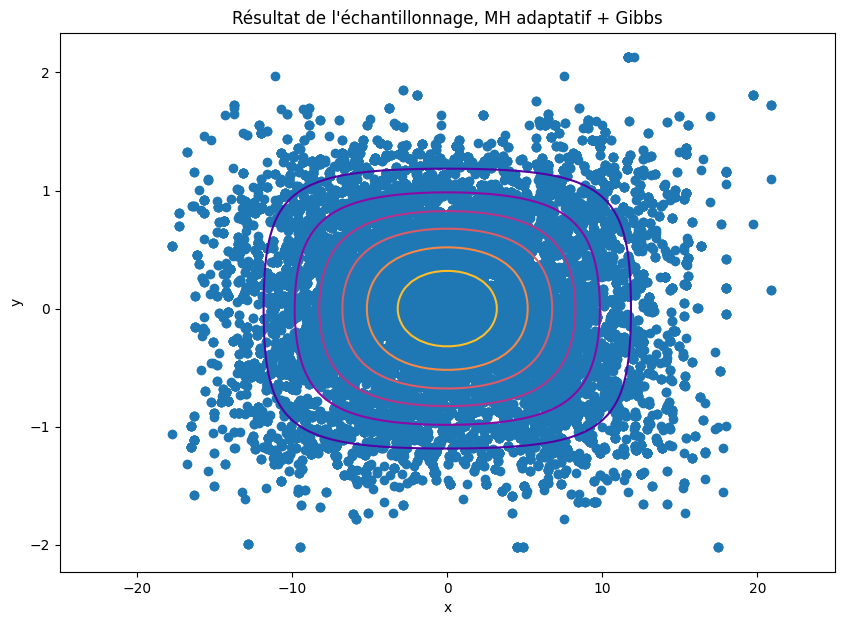

In [511]:
samples_adaptive_plot = np.array(samples_adaptive[10000:]) 
plot_samples(samples_adaptive_plot, lambda z: pi_dist(z, 10), algo_titre="MH adaptatif + Gibbs")


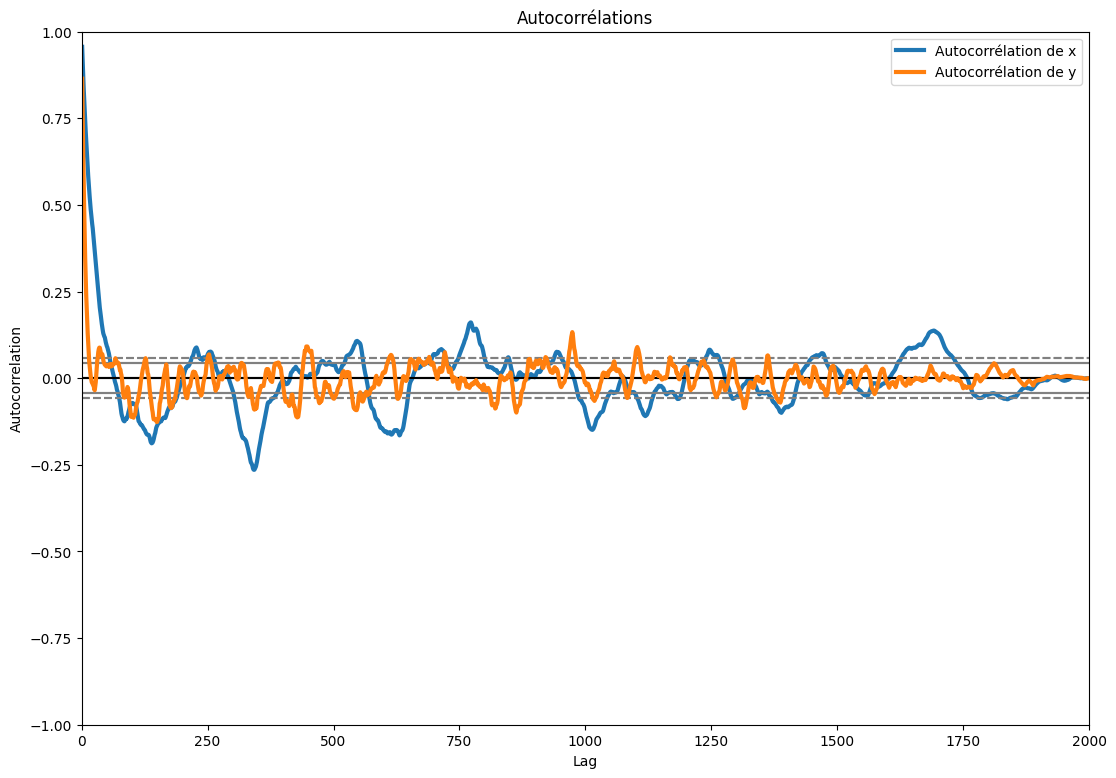

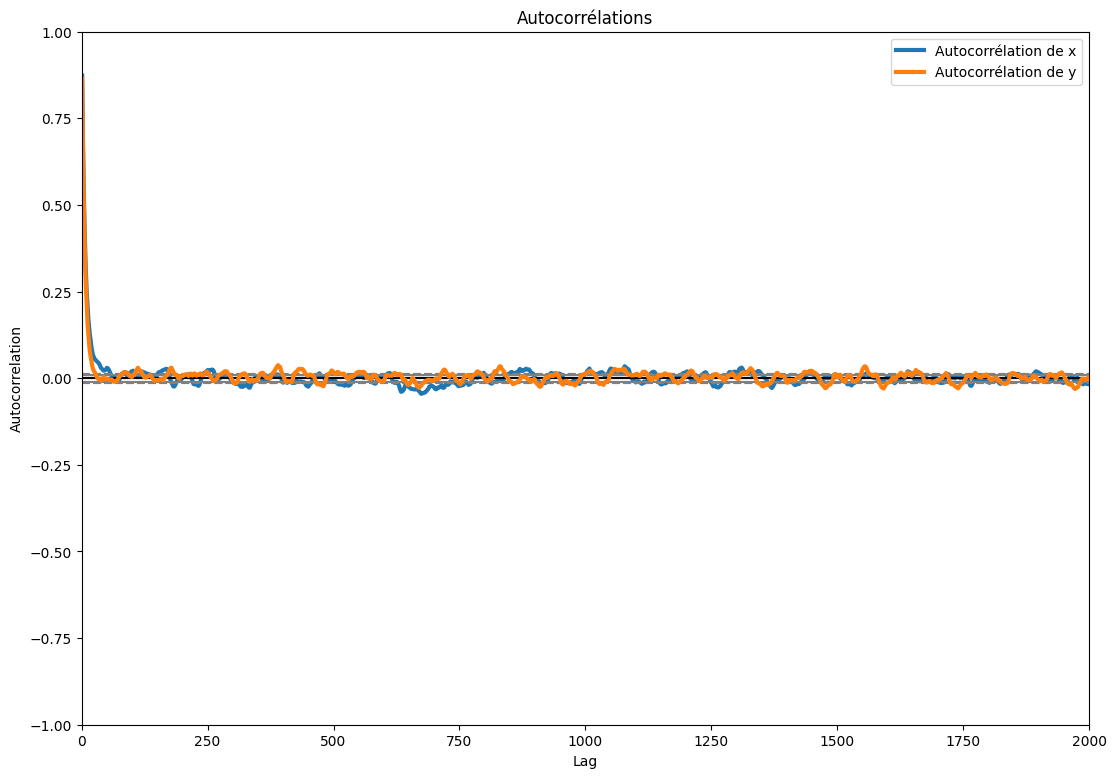

In [512]:
plot_autocorrelations(not_adaptive_samples, max_x=2000)
plot_autocorrelations(samples_adaptive, max_x=2000)


En regardant l’autocorrélation, on voit qu’avec la méthode adaptative, on a une autocorrélation quasi nulle après quelques dizaines d’itérations, alors que sans la méthode adaptative, il nous reste une corrélation même après 1500 itérations. Cela indique que la qualité de notre échantillonnage est bien meilleure avec la méthode adaptative.

### Question 4

In [513]:
def banana_pi_dist(x, B):
    x = np.asarray(x, dtype=float)
    d = x.shape[0]

    x1 = x[0]
    x2 = x[1]
    rest = x[2:]
    
    return np.exp(
        -0.5 * (
            x1**2
            + (x2 + B * x1**2 - B**2)**2
            + np.sum(rest**2)
        )
    )

In [514]:
banana_acc_rates,banana_samples = adaptiveMH_wG([0,0,0,0,0],
                                                 dist=lambda z: banana_pi_dist(z, B=0.4), 
                                                 maxiter=5000, 
                                                 track_every=50)


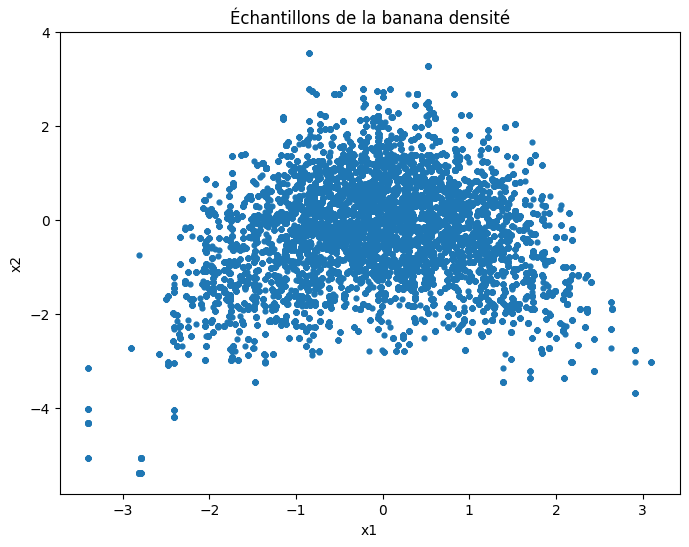

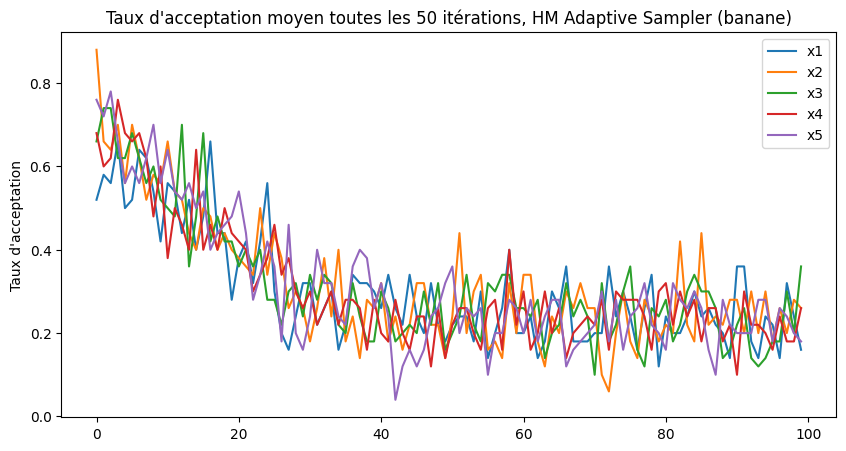

In [515]:
banana_samples = np.array(banana_samples)

plt.figure(figsize=(8, 6))
plt.scatter(banana_samples[:, 0], banana_samples[:, 1], s=12)
plt.title("Échantillons de la banana densité")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

plot_taux_acc(banana_acc_rates, track_every, algo_titre="HM Adaptive Sampler (banane)")


# Exercice 2
## 2.A - A toy example

## Question 1

In [516]:
w = 0.05
sigma = 0.1

In [517]:
mus = np.load('20means.npy') 

In [518]:
def pi(x):
    result = 0
    for i in range(20):
        result += w/(2*np.pi*sigma**2)*np.exp(-(x-mus[i]).T @ ( x-mus[i])/(2*sigma**2))
    return result

def log_pi(x):
    return np.log(pi(x))

## Question 2

In [519]:
# Adapté du tp3 
def SRWMH(z0, sigma_prop, log_dist, maxiter=1000):
    z = [z0]
    z_k = z0

    for k in range(maxiter):
        # proposal
        z_prop = np.random.multivariate_normal(z_k, sigma_prop)
        # acceptation/rejet
        alpha = np.exp(min(0, log_dist(z_prop)-log_dist(z_k)))
        # update (ou non)
        u = np.random.uniform()
        if u < alpha:
            z_k = z_prop
        z.append(z_k)

    return z

In [520]:
def adaptive_SRWMH(z0, sigma2_init, log_dist, maxiter=10000, track_every=50):
    
    z = [z0.copy()]
    z_k = z0.copy()

    sigma2 = np.array(sigma2_init)  # 2x2
    acc = 0

    for j in range(1, maxiter + 1):
        # proposition
        z_prop = np.random.multivariate_normal(z_k, sigma2)

        # acceptation/rejet (en log pour la stabilité)
        log_alpha = min(0.0, log_dist(z_prop) - log_dist(z_k))
        u = np.random.uniform()
        if np.log(u) < log_alpha:
            z_k = z_prop
            acc += 1

        z.append(z_k.copy())

        # adaptation toutes les track_every itérations
        if j % track_every == 0:
            batch = j // track_every
            delta = min(0.05, 1 / np.sqrt(batch))

            taux_acc = acc / track_every

            if taux_acc < 0.234:
                sigma2 = sigma2 / np.exp(2 * delta)
            else:
                sigma2 = sigma2 * np.exp(2 * delta)

            acc = 0

    return np.array(z)


## Question 3

In [521]:
N = 5000
z0 = np.zeros(2)
sigma_prop = np.diag([1.0, 1.0])

samples_mh = np.array(SRWMH(z0, sigma_prop, log_pi, maxiter=N))  

/var/folders/md/4f5pxc7917bdyyrnr824zglh0000gn/T/ipykernel_11140/1756705660.py:8: RuntimeWarning: divide by zero encountered in log
  return np.log(pi(x))


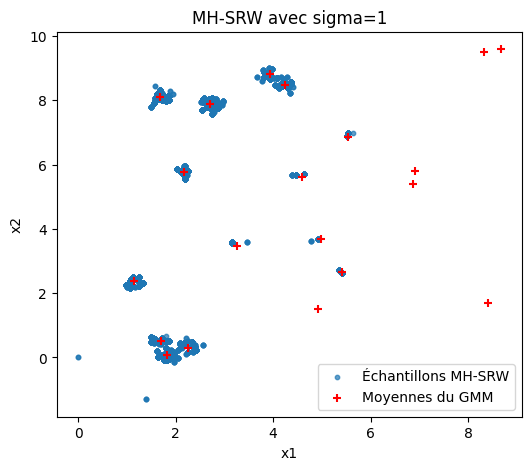

In [522]:

plt.figure(figsize=(6, 5))
plt.scatter(samples_mh[:, 0], samples_mh[:, 1], alpha=0.7, s=10, label="Échantillons MH-SRW")
plt.scatter(mus[:, 0], mus[:, 1], marker="+", color="red", label="Moyennes du GMM")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title(f"MH-SRW avec sigma=1")
plt.legend()
plt.show()

/var/folders/md/4f5pxc7917bdyyrnr824zglh0000gn/T/ipykernel_11140/1756705660.py:8: RuntimeWarning: divide by zero encountered in log
  return np.log(pi(x))


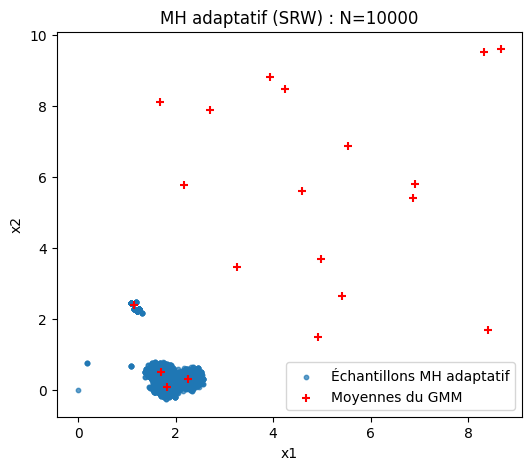

In [532]:
N = 10000
track_every = 50
z0 = np.zeros(2)
sigma2_init = np.diag([1.0, 1.0])

samples_adaptive = adaptive_SRWMH(
    z0, sigma2_init, log_pi, maxiter=N, track_every=track_every
)

plt.figure(figsize=(6, 5))
plt.scatter(samples_adaptive[:, 0], samples_adaptive[:, 1], alpha=0.7, s=10, label="Échantillons MH adaptatif")
plt.scatter(mus[:, 0], mus[:, 1], marker="+", color="red", label="Moyennes du GMM")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title(f"MH adaptatif (SRW) : N={N}")
plt.legend()
plt.show()


L'algorithme de MH classique n'arrive pas à échantillonner selon la distribution donnée. Et avec la méthode adaptative, ça marche encore pire : ce qui se passe, c'est que le taux d'acceptation est trop petit au début car les distributions sont éloignées, donc $\sigma$ diminue. Ensuite, on se retrouve à échantillonner autour une seule gaussienne avec un taux d'acceptation proche d'optimum.

## 2.B - Parallel Tempering
### Question 1
Il est plus simple d'échantillonner la distribution $\pi^{1/T_1}$ car on obtient une distribution plus aplatie. En effet, si on regarde deux points de la distribution $x$ est un mode et $y$ est un point dans la queue, on a le rapport $\pi(x)/\pi(y)$ très grand alors que le rapport $(\pi(x)/\pi(y))^{1/T_1}$ est moins important. 

### Question 2

In [524]:
def parallel_tempering_sampling(z0, log_dist, sigma_MH, temp_list, max_iter=1000):
    K = len(temp_list)
    d = len(z0)

    # Etat courant 
    x_curr = np.tile(z0, (K, 1))

    # Stockage
    all_x = np.empty((max_iter + 1, K, d), dtype=float)
    all_x[0] = x_curr

    for n in range(max_iter):
        # un MH sur chaque temperatire
        prop = np.zeros((K, d))
        for k in range(K):
            prop[k] = SRWMH(x_curr[k], sigma_MH[k], lambda x: log_dist(x) /  temp_list[k], 1)[-1]

        x_next = prop.copy()

        # Proposition de swap
        i, j = np.random.randint(0, K, size=2)
        while i == j: 
            i, j = np.random.randint(0, K, size=2)
        log_alpha = (log_dist(prop[j]) / temp_list[i] + log_dist(prop[i]) / temp_list[j]
                     - log_dist(prop[i]) / temp_list[i] - log_dist(prop[j]) / temp_list[j])
        alpha = np.exp(min(0, log_alpha))

        u = np.random.uniform()
        if u <= alpha:
            x_next[i] = prop[j]
            x_next[j] = prop[i]

        x_curr = x_next.copy()
        all_x[n + 1] = x_curr

    return all_x


### Question 3

In [525]:
K = 5
temp_list = np.array([60, 21.6, 7.7, 2.8, 1.0])

N = 4000
x0 = np.zeros(2)

sigma_MH_const = np.array([np.diag([1, 1]) for _ in range(K)])
X = parallel_tempering_sampling(x0, log_pi, sigma_MH_const, temp_list, max_iter=N)


/var/folders/md/4f5pxc7917bdyyrnr824zglh0000gn/T/ipykernel_11140/1756705660.py:8: RuntimeWarning: divide by zero encountered in log
  return np.log(pi(x))


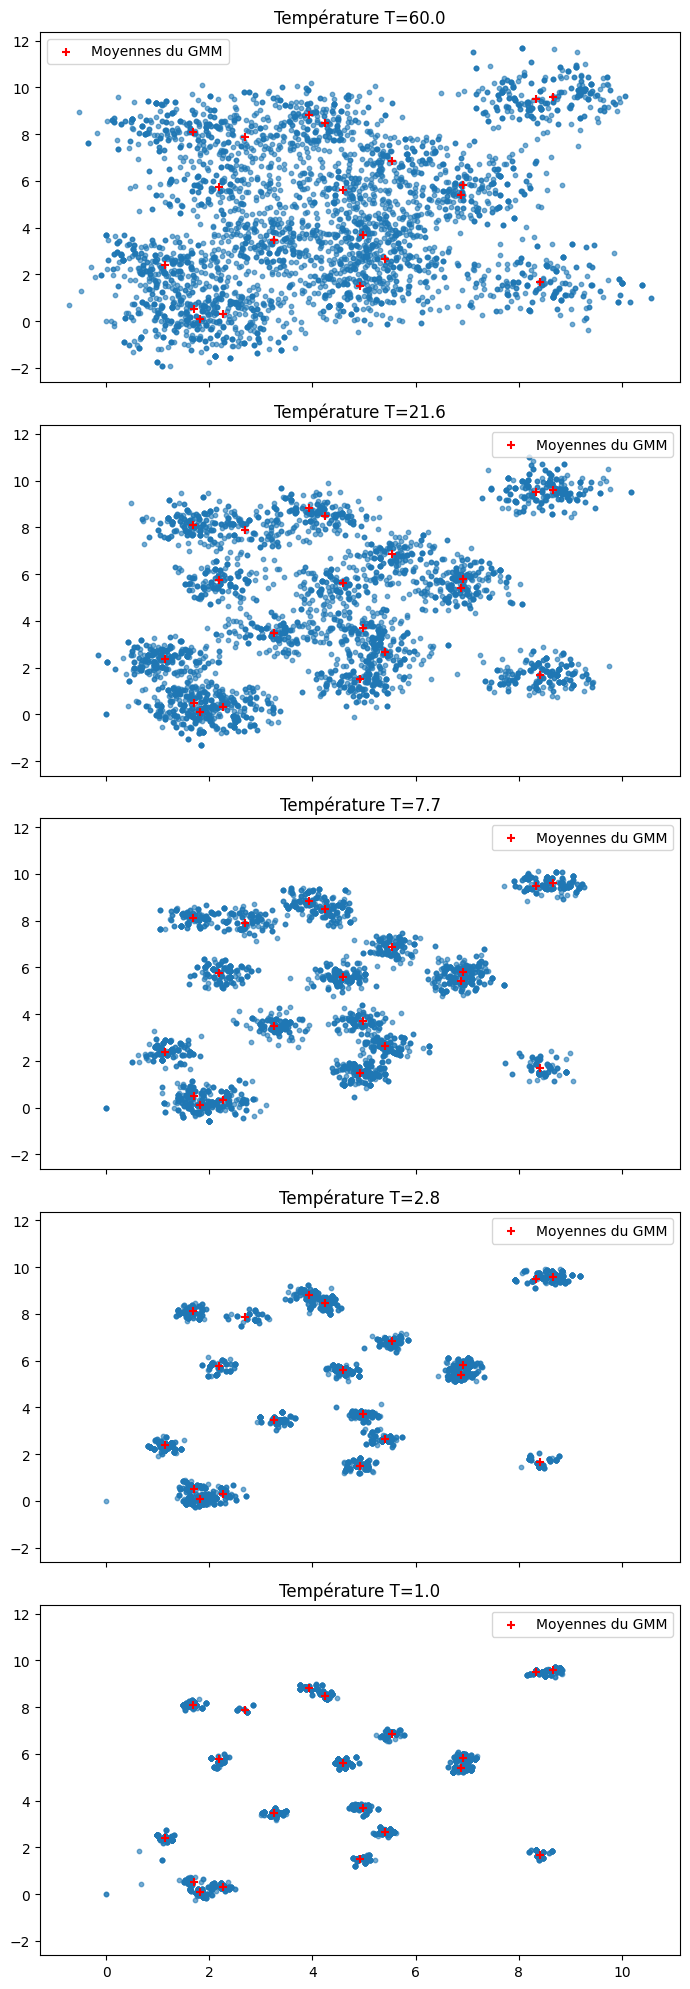

In [526]:
fig, axes = plt.subplots(K, 1, figsize=(7, 4*K), sharex=True, sharey=True)

for i in range(K):
    ax = axes[i]
    ax.scatter(X[:, i, 0], X[:, i, 1], alpha=0.6, s=10)
    ax.scatter(mus[:, 0], mus[:, 1], marker='+', color='red', label='Moyennes du GMM')
    ax.set_title(f"Température T={temp_list[i]}")
    ax.legend()

plt.tight_layout()
plt.show()



In [527]:
tau2 = 0.25 * np.sqrt(temp_list)
sigma_MH_temp = np.array([np.diag([t**2, t**2]) for t in tau2])
X2 = parallel_tempering_sampling(x0, log_pi, sigma_MH_temp, temp_list, max_iter=N)

/var/folders/md/4f5pxc7917bdyyrnr824zglh0000gn/T/ipykernel_11140/1756705660.py:8: RuntimeWarning: divide by zero encountered in log
  return np.log(pi(x))


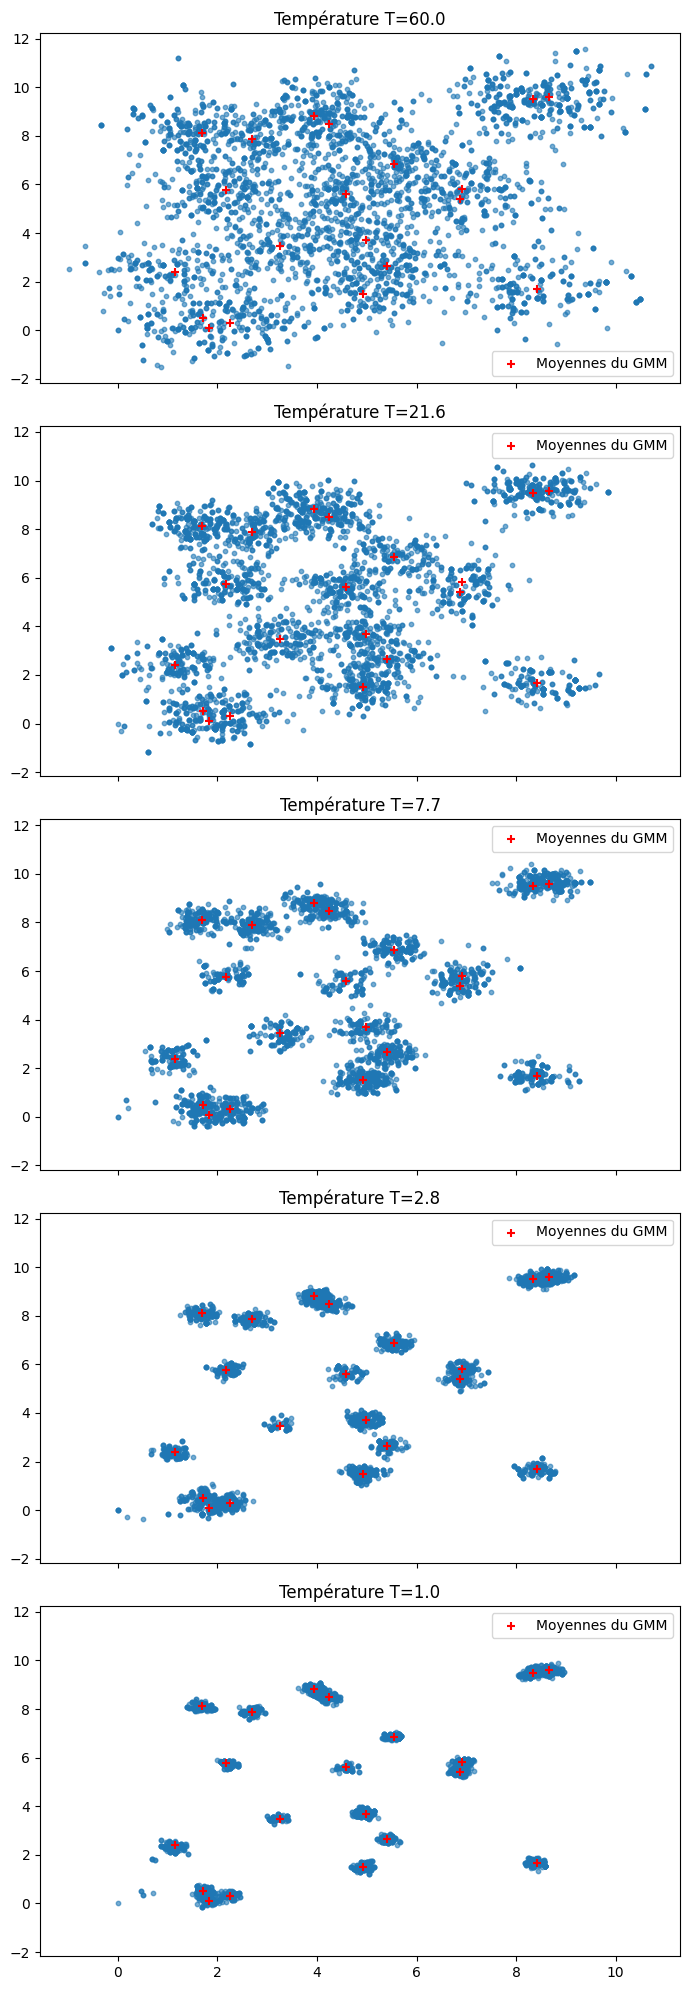

In [528]:
fig, axes = plt.subplots(K, 1, figsize=(7, 4*K), sharex=True, sharey=True)

for i in range(K):
    ax = axes[i]
    ax.scatter(X2[:, i, 0], X2[:, i, 1], alpha=0.6, s=10)
    ax.scatter(mus[:, 0], mus[:, 1], marker='+', color='red', label='Moyennes du GMM')
    ax.set_title(f"Température T={temp_list[i]}")
    ax.legend()

plt.tight_layout()
plt.show()

On observe qu’avec 5 chaînes en parallèle, l’échantillonnage est nettement meilleur. On gardera que la chaîne de Markov pour la température $=1$ car c'est celle qui correspond à la distribution désirée.

# Exercice 3

Avec Bayes on a: 
$$\begin{aligned}
p(X, \mu, \sigma^2, \tau^2 | Y) =
\frac{p(X,\mu, \sigma^2, \tau^2,Y)) }{p(Y)} 
\\= \frac{p(Y|X, \tau^2)\times p(X|\mu, \sigma^2)\times \pi_{prior}(\mu, \sigma^2, \tau^2)}{p(Y)}
\end{aligned}$$

  
Or,
$$\begin{aligned}
p(Y|X,  \tau^2) = \prod_{i=1}^N \prod_{j=1}^{k_i} \mathcal{N}(y_{ij};X_{i},\tau^2)
\\
\propto \frac{1}{\tau^k} \exp\left(-\frac{1}{2\tau^2} \sum_{i=1}^N \sum_{j=1}^{k_i}(y_{i,j}-X_i)^2\right)
\end{aligned}$$

Et
  
$$\begin{aligned}
p(X|\mu, \sigma^2) = \prod_{i=1}^N \mathcal{N}(x_{i};\mu,\sigma^2)\\
\propto \frac{1}{\sigma^N}\exp\left(-\frac{1}{2\sigma^2} \sum_{i=1}^N (x_i - \mu)^2\right)\end{aligned}$$

  

On  a donc en combinant avec le prior: 

$$\begin{aligned}
p(X, \mu, \sigma^2, \tau^2 | Y) 
\propto\frac{1}{\sigma^{2(1+\alpha+N/2)}} \exp\left(- \frac{\beta + \frac{1}{2} \sum_{i=1}^N (X_i - \mu)^2}{\sigma^2}\right) \times \\ \frac{1}{\tau^{2(1+\gamma+k/2)}} \exp\left(- \frac{\beta + \frac{1}{2} \sum_{i=1}^N \sum_{j=1}^{k_i} (Y_{i,j}-X_i)^2}{\tau^2}\right) \end{aligned}$$

## Question 2

On a besoin de connaitre les distributions des paramètres pour échantillonner. En utilisant l'expression précedente:



$$P(\sigma^2|Y,X,\mu,\tau^2) \propto \frac{1}{\sigma^{2(1+\alpha+N/2)}} \exp\left(- \frac{\beta + \frac{1}{2} \sum_{i=1}^N (X_i - \mu)^2}{\sigma^2}\right) $$
Ce qui nou donne inverse gamma de paramètres  $(\frac{N}{2}+\alpha,\beta + \frac{1}{2} \sum_{i=1}^N (X_i - \mu)^2)$

De même: 
$$P(\tau^2|Y,X,\mu,\sigma^2) \propto \frac{1}{\tau^{2(1+\gamma+k/2)}} \exp\left(- \frac{\beta + \frac{1}{2} \sum_{i=1}^N \sum_{j=1}^{k_i} (Y_{i,j}-X_i)^2}{\tau^2}\right)  $$
qui est une inverse gamma de paramètres $(\frac{Nk} {2}+\gamma,\beta + \frac{1}{2} \sum_{i=1}^N \sum_{j=1}^{k_i} (Y_{i,j}-X_i)^2)$
 
 
$$ \begin {aligned} P(\mu|Y,X,\sigma^2,\tau^2) & \propto \exp\left(-\frac{\sum_{i}^N (X_i-\mu)^2}{2\sigma^2}\right) \\
\propto \exp\left(-\frac{(\frac{\sum_{i}^N X_i}{N} - \mu)^2}{2\frac{\sigma^2}{N}}\right)\\
\end{aligned}$$
Ceci nous donne une gaussienne de paramètres $(\bar{X_i}, \frac{\sigma^2}{N})$

Finalement,

$$ \begin{aligned}  P(X|Y,\mu,\sigma^2,\tau^2) & \propto \exp \left(-\frac{\sum_{i}^N (X_i-\mu)^2}{2\sigma^2}\right) \exp \left(-\frac{\sum_{i}^N \sum_{j}^{k_i} (y_{i,j}-X_i)^2}{2\tau^2}\right) \\ 
 \propto \prod_i^N \exp \left( - \frac{((\frac{\tau^2 \mu + \sigma^2 \sum_j^{k_i} y_{i,j}}{\tau^2 + k_i \sigma^2})- X_i)^2}{2 \frac{\sigma^2 \tau^2}{\tau^2 + k_i \sigma^2}} \right)  
\end{aligned}
$$

Par indépendance des $X_i$, on obtient que $X_i$ suit la loi normale des paramètres: $\left(\frac{\tau^2 \mu + \sigma^2 \sum_{j}^{k} y_{i,j} }{k \sigma^2 + \tau^2}, \frac{\tau^2\sigma^2}{\tau^2+k_i\sigma^2}\right)$






In [529]:
def gibbs_sampler(Y, sigma0, tau0, mu0, X0, alpha, beta, gamma, maxiter = 1000):
    X_curr = X0
    mu_curr = mu0 
    sigma2_curr = sigma0
    tau2_curr = tau0
    
    mu_list = [mu_curr]
    sigma2_list = [sigma2_curr]
    tau2_list = [tau2_curr]
    X_list = [X_curr]
    
    N= len(Y)
    
    k = sum([len(Y[i]) for i in range(N)])

    for n in range(maxiter):
        # update sigma, tau, mu
        sigma2_next = invgamma.rvs(N/2 + alpha, scale=(beta + np.sum((X_curr - mu_curr)**2)/2))
        tau2_next = invgamma.rvs(N*k/2 + gamma, scale=(beta + np.sum((Y.T - X_curr)**2)/2))
        mu_next = np.random.normal(np.mean(X_curr), scale=np.sqrt(sigma2_curr/N))
        #update X
        X_next = np.zeros(N)
        for i in range(N): 
            k_i = len(Y[i])
            mean_X = (tau2_curr * mu_curr + sigma2_curr * np.sum(Y[i, :])) / (k_i*sigma2_curr + tau2_curr)
            var_X = sigma2_curr * tau2_curr / (k_i*sigma2_curr + tau2_curr)
            X_next[i] = np.random.normal(loc = mean_X, scale=np.sqrt(var_X))
        
        # update tout le block
        X_curr = X_next
        mu_curr = mu_next 
        sigma2_curr = sigma2_next
        tau2_curr = tau2_next
        
        
        mu_list.append(mu_curr)
        sigma2_list.append(sigma2_curr)
        tau2_list.append(tau2_curr)
        X_list.append(X_curr)
    
    return mu_list, sigma2_list, tau2_list, X_list

In [530]:
# test
N, k = 20, 5
mu_true, sigma2_true, tau2_true = 2.0, 1, 0.5

X_true = np.random.normal(mu_true, np.sqrt(sigma2_true), size=N)
Y = np.random.normal(X_true[:, None], np.sqrt(tau2_true), size=(N, k))

mu_s, sigma2_s, tau2_s, X_s = gibbs_sampler(
    Y, sigma0=1.0, tau0=1.0, mu0=0.0, X0=np.zeros(N),
    alpha=2.0, beta=2.0, gamma=2.0,
    maxiter=3000
)

print(mu_s, sigma2_s, tau2_s, X_s)


[0.0, 0.0598532759665281, 1.699097206274598, 1.6487282791969606, 1.3497613807726525, 2.051086014596492, 1.6952911251598977, 2.2336257687799566, 2.524709433103775, 2.0858582301559485, 1.7726184097109732, 1.5912372521763198, 1.663075740132832, 2.0264900591019983, 1.9816839504308277, 2.0569123093884003, 2.0145002227661624, 1.7495000132548104, 2.066353186225748, 1.7827065701617664, 1.780944007062893, 1.8158322374780238, 1.5809759676508657, 2.441178909867781, 1.9018383621536634, 1.686767172952928, 2.062320982662515, 2.1874243578311807, 2.0261568567816353, 2.188258313886166, 1.8286262253672423, 2.2406295035445405, 2.3833246381152873, 1.7210660056606863, 2.1736326198878717, 1.9811824793811061, 1.9177842877354674, 2.321081062801487, 2.0408063775272822, 2.200949931970687, 1.9638267921813506, 2.3177326021237166, 2.3524621534472834, 1.9766393117085352, 1.8434550266082461, 2.390863396403574, 1.8306186664856479, 2.230278706000372, 2.1043983142586327, 2.111226046746008, 1.8608064896815868, 2.2330443